In [1]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install xlrd

In [3]:
import pandas as pd

In [4]:
train = pd.read_excel("train-FIN_ANA_DATA .xls")
test = pd.read_excel("test-FIN_ANA_DATA .xls")

In [5]:
print("Training data:")
print(train.head())

Training data:
        ACC_NO  INVESTMENT_TOTAL  ACCCURRENTBALANCE INF_MARITAL_STATUS  \
0  27010017245          10720596             585913                  M   
1  27010017436          43455000             585913                  M   
2  27010017458          22012402              68348                  M   
3  27010017493           4893983                  0                  M   
4  27010017515          46254814              68348                  M   

  INF_GENDER  INSTALL_SIZE  DUE_PAYMENT COMPENSATION_CHARGED CLIENT_TYPE  \
0          F           0.0            0                    N  Semi-urban   
1          F           0.0            0                    N  Semi-urban   
2          F           0.0      2744483                    N       Rural   
3          M           0.0            0                    N  Semi-urban   
4          F           0.0            0                    N       Rural   

  QUALITY_OF_LOAN REPAY_MODE  
0               G          N  
1               G    

In [6]:
print("\nTraining shape:", train.shape)
print("\nColumns:")
print(train.columns.tolist())


Training shape: (37408, 11)

Columns:
['ACC_NO', 'INVESTMENT_TOTAL', 'ACCCURRENTBALANCE', 'INF_MARITAL_STATUS', 'INF_GENDER', 'INSTALL_SIZE', 'DUE_PAYMENT', 'COMPENSATION_CHARGED', 'CLIENT_TYPE', 'QUALITY_OF_LOAN', 'REPAY_MODE']


In [7]:
print("\nMissing values:")
print(train.isnull().sum())


Missing values:
ACC_NO                    0
INVESTMENT_TOTAL          0
ACCCURRENTBALANCE         0
INF_MARITAL_STATUS        2
INF_GENDER                2
INSTALL_SIZE            838
DUE_PAYMENT               0
COMPENSATION_CHARGED      2
CLIENT_TYPE             103
QUALITY_OF_LOAN           0
REPAY_MODE                0
dtype: int64


In [8]:
print("QUALITY_OF_LOAN values:")
print(train["QUALITY_OF_LOAN"].value_counts())

QUALITY_OF_LOAN values:
QUALITY_OF_LOAN
G    33254
B     4154
Name: count, dtype: int64


In [9]:
print("\nREPAY_MODE values:")
print(train["REPAY_MODE"].value_counts())


REPAY_MODE values:
REPAY_MODE
N    31583
I     5825
Name: count, dtype: int64


In [10]:
print("\nCLIENT_TYPE values:")
print(train["CLIENT_TYPE"].value_counts())


CLIENT_TYPE values:
CLIENT_TYPE
Rural         26144
Semi-urban     8529
Urban          2629
0                 3
Name: count, dtype: int64


In [11]:
print("\nGENDER values:")
print(train["INF_GENDER"].value_counts())


GENDER values:
INF_GENDER
M    27756
F     9648
O        2
Name: count, dtype: int64


In [12]:
print("\nMARITAL STATUS values:")
print(train["INF_MARITAL_STATUS"].value_counts())


MARITAL STATUS values:
INF_MARITAL_STATUS
M    35412
U     1963
O       31
Name: count, dtype: int64


In [13]:
print(train["QUALITY_OF_LOAN"].value_counts())

QUALITY_OF_LOAN
G    33254
B     4154
Name: count, dtype: int64


In [14]:
# Make a copy
df = train.copy()

In [15]:
# Replace invalid 0 values with missing values
df["INF_GENDER"] = df["INF_GENDER"].replace(0, pd.NA)
df["INF_MARITAL_STATUS"] = df["INF_MARITAL_STATUS"].replace(0, pd.NA)
df["CLIENT_TYPE"] = df["CLIENT_TYPE"].replace(0, pd.NA)

In [16]:
# Fill missing categorical values with the most common value
for col in ["INF_GENDER", "INF_MARITAL_STATUS", "CLIENT_TYPE"]:
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
# Fill missing numerical values with median
for col in ["INSTALL_SIZE"]:
    df[col] = df[col].fillna(df[col].median())

In [18]:
# Remove rows with missing target values
df = df.dropna(subset=["QUALITY_OF_LOAN"])

In [22]:
# Convert COMPENSATION_CHARGED to numeric
df["COMPENSATION_CHARGED"] = pd.to_numeric(
    df["COMPENSATION_CHARGED"],
    errors="coerce"
)

In [23]:
df["COMPENSATION_CHARGED"] = df["COMPENSATION_CHARGED"].fillna(
    df["COMPENSATION_CHARGED"].median()
)


In [24]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
ACC_NO                      0
INVESTMENT_TOTAL            0
ACCCURRENTBALANCE           0
INF_MARITAL_STATUS          0
INF_GENDER                  0
INSTALL_SIZE                0
DUE_PAYMENT                 0
COMPENSATION_CHARGED    37408
CLIENT_TYPE                 0
QUALITY_OF_LOAN             0
REPAY_MODE                  0
dtype: int64


In [25]:
print("\nShape after cleaning:")
print(df.shape)


Shape after cleaning:
(37408, 11)


In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
categorical_columns = [
    "INF_MARITAL_STATUS",
    "INF_GENDER",
    "CLIENT_TYPE",
    "REPAY_MODE"
]

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


In [28]:
# Encode target column
target_encoder = LabelEncoder()
df["QUALITY_OF_LOAN"] = target_encoder.fit_transform(df["QUALITY_OF_LOAN"])

print(df.head())

print("\nTarget values:")
print(df["QUALITY_OF_LOAN"].value_counts())

        ACC_NO  INVESTMENT_TOTAL  ACCCURRENTBALANCE  INF_MARITAL_STATUS  \
0  27010017245          10720596             585913                   0   
1  27010017436          43455000             585913                   0   
2  27010017458          22012402              68348                   0   
3  27010017493           4893983                  0                   0   
4  27010017515          46254814              68348                   0   

   INF_GENDER  INSTALL_SIZE  DUE_PAYMENT  COMPENSATION_CHARGED  CLIENT_TYPE  \
0           0           0.0            0                   NaN            1   
1           0           0.0            0                   NaN            1   
2           0           0.0      2744483                   NaN            0   
3           1           0.0            0                   NaN            1   
4           0           0.0            0                   NaN            0   

   QUALITY_OF_LOAN  REPAY_MODE  
0                1           1  
1       

In [41]:
X = df.drop("QUALITY_OF_LOAN", axis=1)
y = df["QUALITY_OF_LOAN"]

In [42]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (37408, 9)
y shape: (37408,)


In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (29926, 9)
Testing data: (7482, 9)


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [47]:
# Create models
logistic_model = LogisticRegression(max_iter=1000)
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [48]:
# Train models
logistic_model.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
ACC_NO                      0
INVESTMENT_TOTAL            0
ACCCURRENTBALANCE           0
INF_MARITAL_STATUS          0
INF_GENDER                  0
INSTALL_SIZE                0
DUE_PAYMENT                 0
COMPENSATION_CHARGED    37408
CLIENT_TYPE                 0
QUALITY_OF_LOAN             0
REPAY_MODE                  0
dtype: int64


In [39]:
df = df.drop("COMPENSATION_CHARGED", axis=1)

In [40]:
print(df.isnull().sum())

ACC_NO                0
INVESTMENT_TOTAL      0
ACCCURRENTBALANCE     0
INF_MARITAL_STATUS    0
INF_GENDER            0
INSTALL_SIZE          0
DUE_PAYMENT           0
CLIENT_TYPE           0
QUALITY_OF_LOAN       0
REPAY_MODE            0
dtype: int64


In [49]:
print("All 3 models trained successfully!")

All 3 models trained successfully!


In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [51]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}


In [52]:
results = []

In [53]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.8889     0.8889  1.0000    0.9412   0.5805
1        Decision Tree    0.9198     0.9575  0.9520    0.9548   0.8106
2        Random Forest    0.9336     0.9459  0.9814    0.9633   0.9071


In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [55]:
# Predictions
y_pred_rf = random_forest.predict(X_test)


In [56]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

In [57]:
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 458  373]
 [ 124 6527]]


In [58]:
# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)


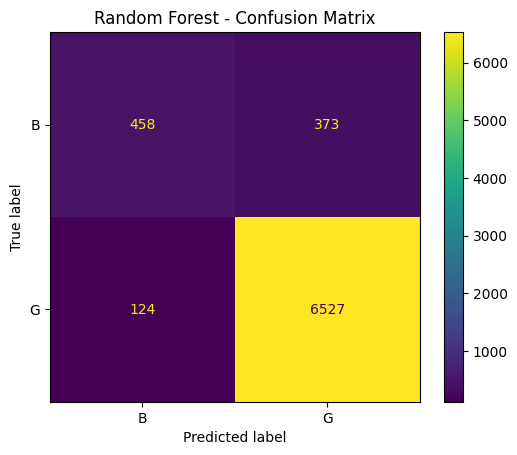

In [59]:
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


In [61]:
# Get prediction probabilities
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]


In [62]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)


In [63]:
# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob_rf)


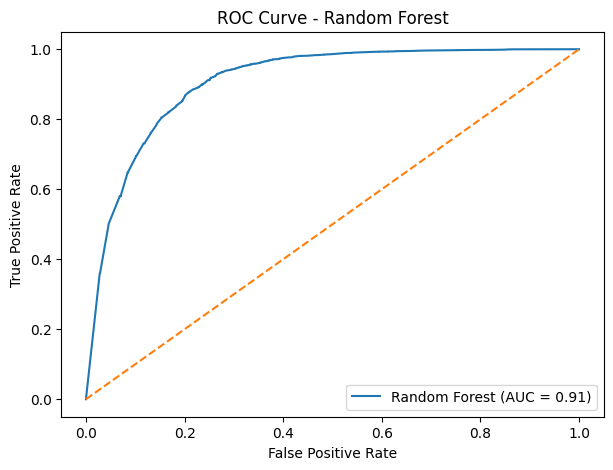

In [65]:
# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [66]:
print("ROC-AUC Score:", round(auc_score, 4))

ROC-AUC Score: 0.9071


In [67]:
import joblib

In [68]:
joblib.dump(random_forest, "credit_scoring_model.pkl")


['credit_scoring_model.pkl']

In [69]:
print("Model saved successfully!")

Model saved successfully!


In [70]:
for col, le in label_encoders.items():
    print(col)
    print(dict(zip(le.classes_, le.transform(le.classes_))))
    print()

INF_MARITAL_STATUS
{'M': np.int64(0), 'O': np.int64(1), 'U': np.int64(2)}

INF_GENDER
{'F': np.int64(0), 'M': np.int64(1), 'O': np.int64(2)}

CLIENT_TYPE
{'Rural': np.int64(0), 'Semi-urban': np.int64(1), 'Urban': np.int64(2)}

REPAY_MODE
{'I': np.int64(0), 'N': np.int64(1)}



In [78]:
def predict_credit_quality(
    acc_no,
    investment_total,
    acc_current_balance,
    marital_status,
    gender,
    install_size,
    due_payment,
    client_type,
    repay_mode
):
    
    # Create input data
    data = pd.DataFrame([{
        "ACC_NO": acc_no,
        "INVESTMENT_TOTAL": investment_total,
        "ACCCURRENTBALANCE": acc_current_balance,
        "INF_MARITAL_STATUS": marital_status,
        "INF_GENDER": gender,
        "INSTALL_SIZE": install_size,
        "DUE_PAYMENT": due_payment,
        "CLIENT_TYPE": client_type,
        "REPAY_MODE": repay_mode
    }])

In [82]:
def predict_credit_quality(
    acc_no,
    investment_total,
    acc_current_balance,
    marital_status,
    gender,
    install_size,
    due_payment,
    client_type,
    repay_mode
):
    # Create input data
    data = pd.DataFrame([{
        "ACC_NO": acc_no,
        "INVESTMENT_TOTAL": investment_total,
        "ACCCURRENTBALANCE": acc_current_balance,
        "INF_MARITAL_STATUS": marital_status,
        "INF_GENDER": gender,
        "INSTALL_SIZE": install_size,
        "DUE_PAYMENT": due_payment,
        "CLIENT_TYPE": client_type,
        "REPAY_MODE": repay_mode
    }])

    # Encode categorical columns
    for col in categorical_columns:
        data[col] = label_encoders[col].transform(
            data[col].astype(str)
        )

    # Make prediction
    prediction = random_forest.predict(data)[0]
    probability = random_forest.predict_proba(data)[0]

    # Convert prediction back to B/G
    result = target_encoder.inverse_transform([prediction])[0]

    print("Predicted Loan Quality:", result)
    print("Prediction Probability:", round(max(probability) * 100, 2), "%")

    return result

In [83]:
sample = train.iloc[0]
print(sample)

ACC_NO                  27010017245
INVESTMENT_TOTAL           10720596
ACCCURRENTBALANCE            585913
INF_MARITAL_STATUS                M
INF_GENDER                        F
INSTALL_SIZE                    0.0
DUE_PAYMENT                       0
COMPENSATION_CHARGED              N
CLIENT_TYPE              Semi-urban
QUALITY_OF_LOAN                   G
REPAY_MODE                        N
Name: 0, dtype: object


In [84]:
prediction = predict_credit_quality(
    acc_no=27010017245,
    investment_total=10720596,
    acc_current_balance=585913,
    marital_status="M",
    gender="F",
    install_size=0.0,
    due_payment=0,
    client_type="Semi-urban",
    repay_mode="N"
)


Predicted Loan Quality: G
Prediction Probability: 94.0 %


In [85]:
print("Final Prediction:", prediction)

Final Prediction: G
